## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Get data

In [2]:
titanic_train_data = pd.read_csv('titanic/train.csv')
print(titanic_train_data.shape)

(891, 12)


## 2. Prepare data for algs

### 2.1 Pipeline

In [3]:
from sklearn.preprocessing import StandardScaler, QuantileTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import TransformerMixin, BaseEstimator

def build_pipeline():
    num_features = ['Age', 'Fare']
    cat_features = ['Sex', 'Embarked']
    passthrough_features = ['Pclass', 'SibSp', 'Parch']
    
    # create a special class for imputing 'Age' using 'Pclass', 'Sex' and 'Fare'
    class AgeImputer(BaseEstimator, TransformerMixin):
        def fit(self, X, y=None):
            X = X.copy()
            X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})
            
            # Get rows where Age is known
            known_age = X['Age'].notna()
            X_train = X.loc[known_age, ['Pclass', 'Sex', 'Fare']]
            y_train = X.loc[known_age, 'Age']
            
            # Preprocess features
            self.preproc = ColumnTransformer([
                ('num', SimpleImputer(strategy='median'), ['Pclass', 'Fare'])
            ])
            X_trans = self.preproc.fit_transform(X_train)
    
            # Fit model
            self.model = RandomForestRegressor(random_state=42)
            self.model.fit(X_trans, y_train)
            return self
    
        def transform(self, X):
            X = X.copy()
            X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})
            
            # Predict missing Ages
            missing_age = X['Age'].isna()
            X_pred = X.loc[missing_age, ['Pclass', 'Sex', 'Fare']]
            X_pred_trans = self.preproc.transform(X_pred)
            pred_ages = self.model.predict(X_pred_trans)
    
            # Filling missing values
            X.loc[missing_age, 'Age'] = pred_ages
            return X
    
    
    # separate numeric pipelines for Age and Fare
    age_pipeline = Pipeline([
        ('age_imputer', AgeImputer()),
        ('scaler_age', StandardScaler()),
    ])
    
    fare_pipeline = Pipeline([
        ('imputer', KNNImputer(n_neighbors=5)),  
        ('transformer_fare', QuantileTransformer(n_quantiles=100))    
    ])
    
    # for 'Sex' and 'Embarked' attributes
    categorical_pipeline = Pipeline([
        ('imputer_embarked', SimpleImputer(strategy='most_frequent')),
        ('ordinal', OrdinalEncoder(categories=[
            ['female', 'male'],
            ['C', 'Q', 'S']
        ]))
    ])
    
    # Apply to columns with seperate numeric pipelines
    preprocessor = ColumnTransformer([
        ('age', age_pipeline, ['Age', 'Pclass', 'Sex', 'Fare']),
        ('fare', fare_pipeline, ['Fare']),
        ('cat', categorical_pipeline, cat_features),
        ('pass', 'passthrough', passthrough_features), # keep as is
    ])
    
    # drop unwanted columns before applying preprocessor
    class ColumnDropper(TransformerMixin):
        def fit(self, X, y=None):
            return self
        def transform(self, X):
            return X.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
    
    final_pipeline = Pipeline([
        ('drop_cols', ColumnDropper()),
        ('preprocess', preprocessor)
    ])

    return final_pipeline

print('pipeline ready')

pipeline ready


In [4]:
# prepare our data 
def prepare_data(X_train, y_train, X_val, y_val):
    # create pipeline instance
    pipeline = build_pipeline()

    # fit & transform the X data
    X_train_prepared = pipeline.fit_transform(X_train).astype('float32')
    X_val_prepared = pipeline.transform(X_val).astype('float32')

    # prepare y data as well
    y_train_prepared = np.asarray(y_train).astype('float32')
    y_val_prepared = np.asarray(y_val).astype('float32')

    return X_train_prepared, y_train_prepared, X_val_prepared, y_val_prepared

## 3. Train 

### base model

In [6]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow import keras

# function to create models
def build_model():
    model = models.Sequential([
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [24]:
from matplotlib import pyplot as plt

class LossHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs):
        self.per_batch_losses = []

    def on_batch_end(self, batch, logs):
        self.per_batch_losses.append(logs.get("loss"))

    def on_epoch_end(self, epoch, logs):
        plt.clf()
        plt.plot(range(len(self.per_batch_losses)), self.per_batch_losses,
                label="Training loss for each batch")
        plt.xlabel(f"Batch (epoch {epoch})")
        plt.ylabel("Loss")
        plt.legend()
        plt.savefig(f"plots/plot_at_epoch_{epoch}")
        self.per_batch_losses = []

# k-fold cv
def train_model(train_set, epochs, batch_size=128, k=4):
    filepath='checkpoint_models/model3.keras'
    num_of_val_samples = len(train_set) // k

    indices = [i for i in range(0, len(train_set))]
    np.random.shuffle(indices) # shuffle the indices for the entire train_set for k-fold split
    shuffled_set = train_set.iloc[indices]
    train_data, train_labels = shuffled_set.drop('Survived', axis=1), shuffled_set['Survived'] # X & y 
    train_data_columns = train_data.columns
    
    all_acc_histories = []
    all_loss_histories = []
    
    for i in range(k):
        print('processing fold: #', i)
        # create the val sets for the current k-fold
        val_data = train_data[i*num_of_val_samples: (i+1)*num_of_val_samples]
        val_labels = train_labels[i*num_of_val_samples: (i+1)*num_of_val_samples]

        # train sets for the current (k-1) fold 
        partial_train_data = np.concatenate([
            train_data[:i*num_of_val_samples],
            train_data[(i+1)*num_of_val_samples:]],
            axis=0
        )
        partial_train_labels = np.concatenate([
            train_labels[:i*num_of_val_samples],
            train_labels[(i+1)*num_of_val_samples:]],
            axis=0
        )

        # instantiate a new model
        model = build_model()

        # prepare the data
        partial_train_data_df = pd.DataFrame(partial_train_data, columns=train_data_columns)
        partial_train_labels_df = pd.DataFrame(partial_train_labels, columns=['Survived'])

        val_data_df = pd.DataFrame(val_data, columns=train_data_columns)
        val_labels_df = pd.DataFrame(val_labels, columns=['Survived'])
        
        X_train_prepared, y_train_prepared, X_val_prepared, y_val_prepared = prepare_data(partial_train_data_df, partial_train_labels_df, val_data_df, val_labels_df)

        # train it
        callbacks_list = [
            keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=3,
            ),
            keras.callbacks.ModelCheckpoint(
                filepath=filepath,
                monitor='val_loss',
                save_best_only=True,
            ),
            keras.callbacks.TensorBoard(
                log_dir="logs/log_file1",
            ),
            LossHistory()
        ]
        history = model.fit(X_train_prepared, y_train_prepared, epochs=epochs, callbacks=callbacks_list, batch_size=batch_size, validation_data=(X_val_prepared, y_val_prepared))
        acc_history = history.history['val_accuracy']
        loss_history = history.history['val_loss']
        all_acc_histories.append(acc_history)
        all_loss_histories.append(loss_history)

    return all_acc_histories, all_loss_histories, model

processing fold: # 0
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.6459 - loss: 0.6256 - val_accuracy: 0.7528 - val_loss: 0.5347
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7681 - loss: 0.5241 - val_accuracy: 0.8315 - val_loss: 0.4564
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7805 - loss: 0.4994 - val_accuracy: 0.7978 - val_loss: 0.4533
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7868 - loss: 0.4810 - val_accuracy: 0.8202 - val_loss: 0.4298
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7980 - loss: 0.4599 - val_accuracy: 0.8427 - val_loss: 0.4121
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8042 - loss: 0.4493 - val_accuracy: 0.8315 - val_loss: 0.4055
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7905 - loss: 0.4543 - val_accuracy: 0.8652 - val_loss: 0.4158
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7993 - loss: 0.4518 - val_accuracy: 0.842

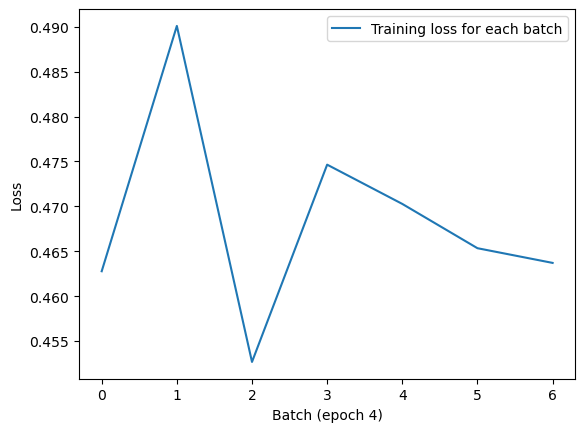

In [25]:
# train the model
total_acc_histories, total_loss_histories, my_model = train_model(titanic_train_data, epochs=50, k=10)

In [26]:
one_big_list = []
loss_list = []

for acc_list in total_acc_histories:
    for num in acc_list:
        one_big_list.append(num)
print(np.max(one_big_list))

for lss_list in total_loss_histories:
    for lss in lss_list:
        loss_list.append(lss)
print(np.min(loss_list))

0.8651685118675232
0.3712489902973175


### model #2

In [123]:
model2 = models.Sequential([
    layers.Dense(16, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [125]:
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history2 = model2.fit(X_train_prepared, y_train_prepared, epochs=20, batch_size=8, validation_data=(X_val_prepared, y_val_prepared))

Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8539 - loss: 0.3687 - val_accuracy: 0.7933 - val_loss: 0.4853
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8652 - loss: 0.3610 - val_accuracy: 0.7989 - val_loss: 0.4363
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8567 - loss: 0.3567 - val_accuracy: 0.7765 - val_loss: 0.4435
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8539 - loss: 0.3560 - val_accuracy: 0.8045 - val_loss: 0.4567
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8638 - loss: 0.3495 - val_accuracy: 0.8045 - val_loss: 0.4348
Epoch 6/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8652 - loss: 0.3464 - val_accuracy: 0.8101 - val_loss: 0.4687
Epoch 7/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8652 - loss: 0.3482 - val_accuracy: 0.8045 - val_loss: 0.4497
Epoch 8/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8652 - loss: 0.3446 - val_accuracy: 0.7877 - val_loss:

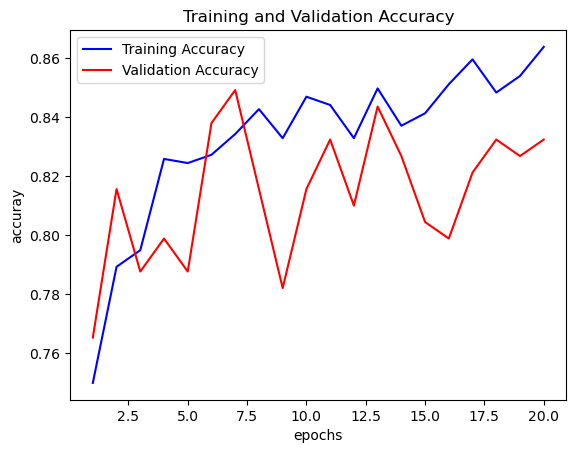

In [76]:
train_acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
plt.plot(epochs, train_acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuray')
plt.legend()
plt.show()